# Actor Categorization and Filtering

In many text analysis scenarios, extracting exact actors (e.g., "the senior engineer", "a young intern") is just the first step. To gain broader insights, you often need to group these specific actors into macro-categories (e.g., "Engineering", "Leadership").

This tutorial demonstrates how to:
1. Use `teanets` to extract SVO (Subject-Verb-Object) triples from a text.
2. Apply a rule-based categorization to group the extracted Agents into custom classes.
3. Use these categories to filter the data and generate targeted semantic networks with `teanets`.

## 1. Extracting SVOs from Text

Let's start by defining a sample text about a corporate environment and extracting its SVOs using `teanets`.

In [15]:
import teanets as tea
import pandas as pd
import re

text = """
The CEO announced a new strategy. The marketing manager launched the campaign. 
The developers built the new application. A young intern broke the main server. 
The CEO praised the developers. The marketing manager blamed the intern. 
Our senior engineer fixed the server quickly.
"""

# Extract the semantic network dataframe
df_svo = tea.extract_svos_from_text(text)
display(df_svo)

Inference: 100%|██████████| 1/1 [00:00<00:00, 47.95it/s]


,Node 1,TEA,Node 2,TEA2,Hypergraph,Semantic-Syntactic,svo_id,passive_approx,is_passive
0,ceo,Agent,announce,Event,"[[('ceo', [])], ['announce'], [('new strategy'...",0,0,0,0
1,announce,Event,new strategy,Target,"[[('ceo', [])], ['announce'], [('new strategy'...",0,0,0,0
2,marketing manager,Agent,launch,Event,"[[('marketing manager', [])], ['launch'], [('c...",0,1,0,0
3,launch,Event,campaign,Target,"[[('marketing manager', [])], ['launch'], [('c...",0,1,0,0
4,developer,Agent,build,Event,"[[('developer', [])], ['build'], [('new applic...",0,2,0,0
5,build,Event,new application,Target,"[[('developer', [])], ['build'], [('new applic...",0,2,0,0
6,young intern,Agent,break,Event,"[[('young intern', [])], ['break'], [('main se...",0,3,0,0
7,break,Event,main server,Target,"[[('young intern', [])], ['break'], [('main se...",0,3,0,0
8,ceo,Agent,praise,Event,"[[('ceo', [])], ['praise'], [('developer', [])...",0,4,0,0
9,praise,Event,developer,Target,"[[('ceo', [])], ['praise'], [('developer', [])...",0,4,0,0


## 2. Defining Categorization Rules

The extracted `Node 1` (Agent) column contains very specific noun chunks. We will define a set of keyword rules to classify these agents into organizational departments.

In [16]:
department_rules = [
    ('Leadership', ['ceo', 'director', 'president', 'executive']),
    ('Marketing', ['marketing', 'sales', 'pr', 'communications']),
    ('Engineering', ['developer', 'engineer', 'intern', 'programmer', 'cto'])
]

def categorize_agent(agent_str):
    """Categorizes an agent string based on predefined keyword rules."""
    if not isinstance(agent_str, str):
        return 'Other'
    
    # Normalize to lowercase for matching
    agent_str = agent_str.lower()
    
    for category, keywords in department_rules:
        # Sort keywords by length to match multi-word terms first if necessary
        for keyword in sorted(keywords, key=len, reverse=True):
            # Use word boundaries (\b) to avoid partial matches (e.g., 'man' in 'manager')
            if re.search(rf'\b{re.escape(keyword)}\b', agent_str):
                return category
                
    return 'Other'

# Apply the categorization to the Agents (Node 1)
df_svo['Department'] = df_svo.apply(lambda row: categorize_agent(row['Node 1']) if row['TEA'] == 'Agent' else 'Other', axis=1)
display(df_svo[['Node 1', 'Department', 'Node 2', 'TEA2']])

,Node 1,Department,Node 2,TEA2
0,ceo,Leadership,announce,Event
1,announce,Other,new strategy,Target
2,marketing manager,Marketing,launch,Event
3,launch,Other,campaign,Target
4,developer,Engineering,build,Event
5,build,Other,new application,Target
6,young intern,Engineering,break,Event
7,break,Other,main server,Target
8,ceo,Leadership,praise,Event
9,praise,Other,developer,Target


## 3. Targeted Analysis and Visualization

Now that our nodes are enriched with categorical metadata, we can perform targeted analyses. For instance, we can isolate all actions performed by the **Engineering** department and plot a subgraph using `teanets`.

Total actions by Engineering: 3


,Node 1,TEA,Node 2,TEA2,Hypergraph,Semantic-Syntactic,svo_id,passive_approx,is_passive,Department
4,developer,Agent,build,Event,"[[('developer', [])], ['build'], [('new applic...",0,2,0,0,Engineering
5,build,Event,new application,Target,"[[('developer', [])], ['build'], [('new applic...",0,2,0,0,Other
6,young intern,Agent,break,Event,"[[('young intern', [])], ['break'], [('main se...",0,3,0,0,Engineering
7,break,Event,main server,Target,"[[('young intern', [])], ['break'], [('main se...",0,3,0,0,Other
12,our senior engineer,Agent,fix quickly,Event,"[[('our senior engineer', [])], ['fix quickly'...",0,6,0,0,Engineering
13,fix quickly,Event,server,Target,"[[('our senior engineer', [])], ['fix quickly'...",0,6,0,0,Other


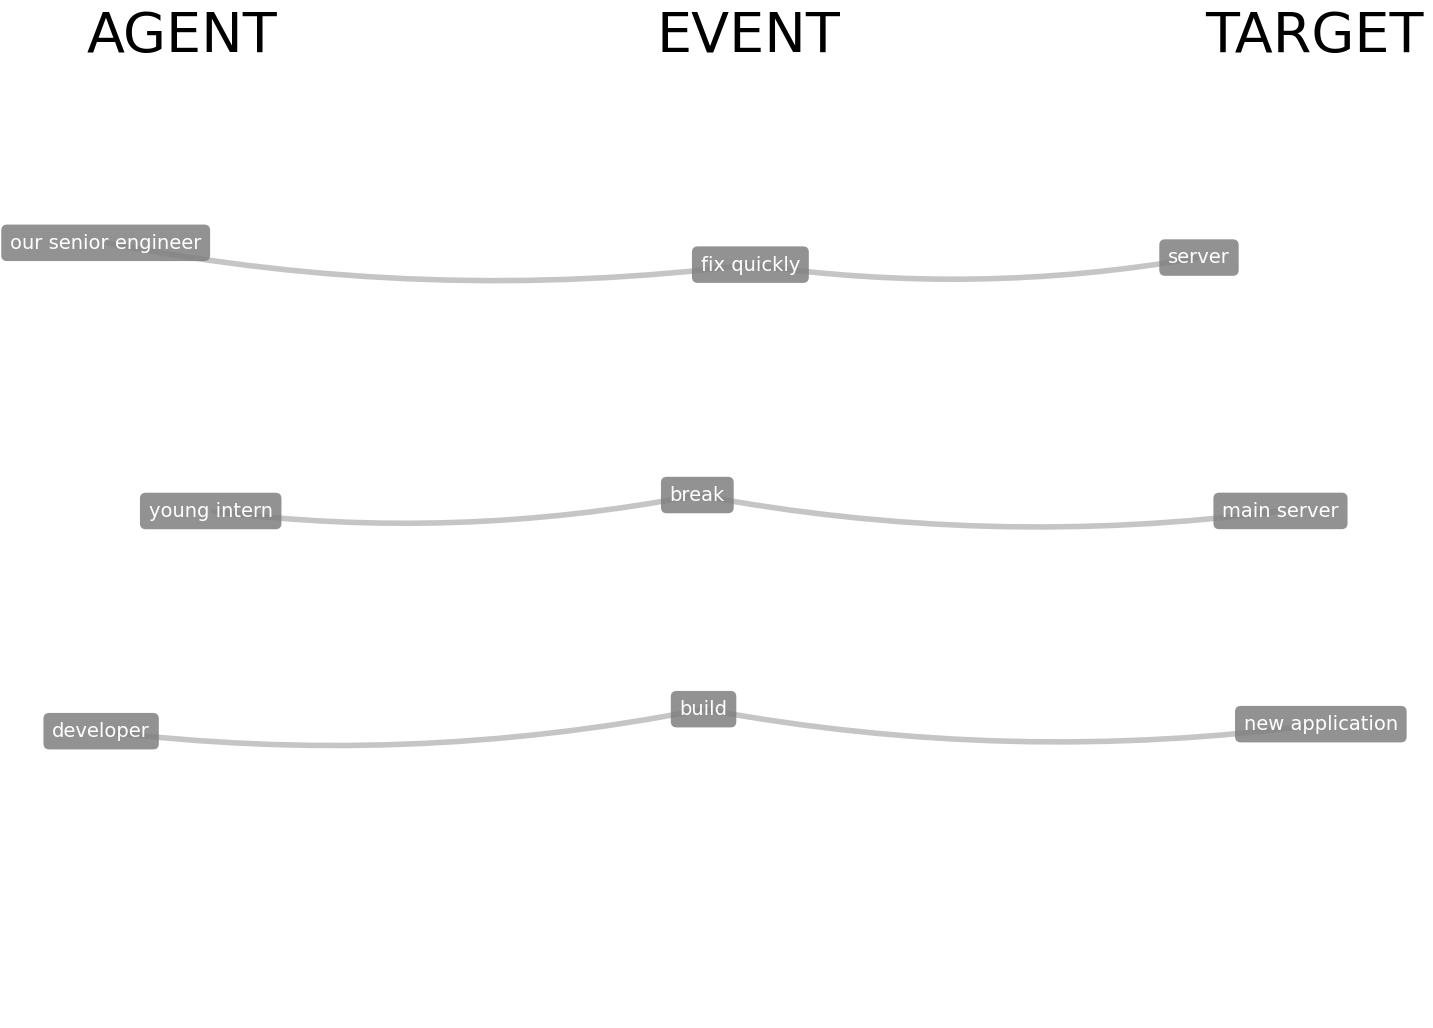

In [17]:
# Filter the DataFrame for Engineering actions
engineering_svo_ids = df_svo[df_svo['Department'] == 'Engineering']['svo_id'].unique()
engineering_df = df_svo[df_svo['svo_id'].isin(engineering_svo_ids)].copy()

# Plot the SVO graph specifically for this subset of the data
print(f"Total actions by Engineering: {len(engineering_svo_ids)}")
display(engineering_df)
tea.plot_svo_graph(engineering_df)

### Conclusion
By combining `teanets`' robust SVO extraction with simple Python post-processing, you can effectively map complex narratives into high-level categorical interactions, allowing for macro-scale analysis of texts.